# 2 — Models, policies and results

This notebook reads the artefacts produced by

```
python -m src.models.evaluate
python -m src.experiments.run_comparison
python -m src.experiments.stress_test
```

and works through what they say — including the parts that did not work, which are the more interesting parts.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import CONFIG, REPORTS_DIR
from src.policies.routing import route_nn_2opt, route_s_shape

plt.rcParams.update({'figure.figsize': (10, 4), 'axes.grid': True, 'grid.alpha': 0.3})
pd.set_option('display.width', 200)

def report(name):
    path = REPORTS_DIR / name
    return pd.read_csv(path) if path.exists() else None

## 1. ML-1 — demand forecasting

One global gradient-boosted model across all SKUs, validated walk-forward: train up to a cut-off, predict the next week, roll the cut-off forward. A random split would leak the future into the past.

The metric is WMAPE, not MAPE. Daily SKU demand is full of zeros and MAPE is undefined the moment the actual is zero — it would be arithmetically meaningless on exactly the items that are hardest.

In [2]:
backtest = report('model_demand_backtest.csv')
cols = ['fold', 'train_days', 'test_start', 'test_end', 'model_wmape',
        'naive_last_wmape', 'seasonal_naive_wmape', 'moving_average_28_wmape',
        'improvement_vs_best_naive']
display(backtest[cols].round(4))

best_naive = backtest[['naive_last_wmape', 'seasonal_naive_wmape', 'moving_average_28_wmape']].min(axis=1)
print(f"mean model WMAPE      {backtest['model_wmape'].mean():.4f}")
print(f"mean best-naive WMAPE {best_naive.mean():.4f}")
print(f"improvement           {100 * backtest['improvement_vs_best_naive'].mean():.1f}%")

,fold,train_days,test_start,test_end,model_wmape,naive_last_wmape,seasonal_naive_wmape,moving_average_28_wmape,improvement_vs_best_naive
0,0,396,2024-03-01,2024-03-07,0.7245,1.0896,0.9089,0.7844,0.0764
1,1,389,2024-02-23,2024-02-29,0.7258,1.0472,1.0871,0.8047,0.0981
2,2,382,2024-02-16,2024-02-22,0.7946,1.2337,1.0225,0.9342,0.1495
3,3,375,2024-02-09,2024-02-15,0.8150,1.1353,1.1126,0.9834,0.1713


mean model WMAPE      0.7650
mean best-naive WMAPE 0.8767
improvement           12.4%


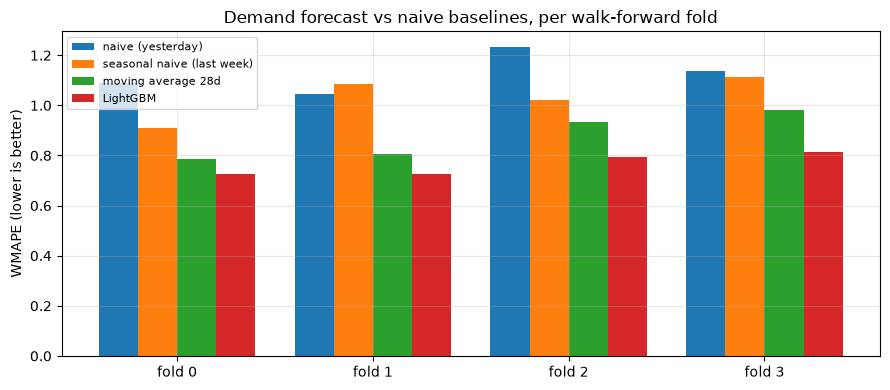

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
width = 0.2
x = np.arange(len(backtest))
for i, (col, label) in enumerate([
    ('naive_last_wmape', 'naive (yesterday)'),
    ('seasonal_naive_wmape', 'seasonal naive (last week)'),
    ('moving_average_28_wmape', 'moving average 28d'),
    ('model_wmape', 'LightGBM'),
]):
    ax.bar(x + i * width, backtest[col], width, label=label)
ax.set_xticks(x + 1.5 * width); ax.set_xticklabels([f'fold {i}' for i in backtest['fold']])
ax.set_ylabel('WMAPE (lower is better)'); ax.legend(fontsize=8)
ax.set_title('Demand forecast vs naive baselines, per walk-forward fold')
plt.tight_layout(); plt.show()

**A WMAPE around 0.77 sounds bad, and is not.** Most of these SKUs sell a handful of units on a handful of days; at daily granularity that is close to irreducible. The number that matters is the gap to the naive rules, and the model beats the best of them consistently across every fold.

A 90% improvement here would have been a warning sign, not a triumph — it would mean a feature was leaking the answer.

## 2. ML-2 — pick time, and an honest baseline

Two baselines are reported. `analytic_standard` is the textbook formula handed the *exact* constants the simulator uses — deliberately unfair to the model, and included to show how little room is left once the physical drivers are accounted for. `linear_timestudy` fits those same coefficients from observed tours, which is what an industrial engineer actually produces, and is the fair comparator.

In [4]:
pick = report('model_pick_time.csv')
display(pick.round(4))

mae = pick.set_index('estimator')['mae_s']
if 'linear_timestudy' in mae.index:
    print(f"vs linear time study : {100 * (1 - mae['lightgbm'] / mae['linear_timestudy']):+.1f}% MAE")
print(f"vs oracle formula    : {100 * (1 - mae['lightgbm'] / mae['analytic_standard']):+.1f}% MAE")

,estimator,mae_s,rmse_s,mape,r2,n_test_tours
0,analytic_standard,193.0876,273.0719,0.1467,0.8084,2306
1,linear_timestudy,183.0518,254.2213,0.1519,0.8339,2306
2,lightgbm,183.8398,256.2256,0.1518,0.8313,2306


vs linear time study : -0.4% MAE
vs oracle formula    : +4.8% MAE


The model does **not** beat the time study (about −0.4% on MAE) and gains only ~5% on the oracle-constant formula. That is the correct result, not a disappointment: pick time really is close to linear in lines, units and distance, so a flexible model has almost nothing left to find. Congestion is the one thing the formula cannot express, and picker-specific and residual variation are deliberately unobservable, so a ceiling is built in.

A model that scored near-perfectly here would mean the hidden factors were not actually hidden.

Downstream it matters even less. Swapping the analytic estimate for this model leaves the dispatch policy's on-time rate unchanged to four decimal places, because both produce the same *ordering* of the queue even where their absolute predictions differ. An accuracy gain that does not change a decision is not worth deploying.

## 3. ML-3 — SLA risk

Binary: will this order miss its truck? Trained on snapshots logged every 15 simulated minutes during a baseline run, labelled afterwards with the outcome. The comparator is ranking by slack alone.

In [5]:
risk = report('model_sla_risk.csv')
display(risk.round(4))

,model,roc_auc_pooled,roc_auc_within_decision,average_precision,brier,n_test_snapshots,positive_rate
0,slack_only,0.8466,0.6243,0.2543,0.0299,72208,0.0332
1,lightgbm,0.7818,0.8175,0.0704,0.0967,72208,0.0332


Four metrics, and they disagree. That disagreement is the finding.

- **Pooled AUC** is *worse* than slack (0.78 vs 0.85). Pooling every snapshot together rewards separating busy periods from quiet ones — which slack, being a time-varying quantity, does well.
- **Within-decision AUC** is much *better* (0.82 vs 0.62). Grouping by snapshot asks the question a dispatcher actually faces: can you rank the orders competing for the next picker, right now? On that question the model wins clearly.
- **Average precision** is a third of slack's (0.07 vs 0.25), and the **Brier score** three times worse (0.097 vs 0.030). These describe the *top* of the ranking and its calibration.

Read together: the model orders the bulk of the queue well but is unreliable and over-confident at the very top. An escalation policy spends nothing *but* the top — so it promotes the wrong orders, and section 5 shows the on-time rate falling as a result.

Which metric mattered was decided by how the score gets used, not by convention. No single offline number would have caught this; the end-to-end simulation did.

There is also a structural caveat worth stating plainly: the model is trained under one dispatch policy and then used to change that policy, so the distribution it was fitted on shifts underneath it the moment it starts acting. That is the standard feedback-loop problem in operational ML, not an artefact of simulation, and a further reason to judge the policy end-to-end.

## 4. Why routing has anything to optimise

Before the results, a structural point that shaped the whole warehouse design.

With a **single** cross aisle, a tour's cost is

$$\text{total} = 2\sum_i y_i + (\text{a one-dimensional traversal in } x)$$

The first term does not depend on the visiting order at all — every stop must be entered and exited from the same end — and the second is already minimised by sorting on aisle, which is what S-shape does. **No routing heuristic can win.** Adding cross aisles gives the picker a choice of exit, the cost stops decomposing, and routing becomes a real problem.

,cross_aisles,s_shape_m,nn_2opt_m,routing_gain_pct
0,1,822.84,822.84,0.00
1,2,578.27,513.92,11.13
2,3,448.47,379.76,15.32
3,4,418.14,327.32,21.72


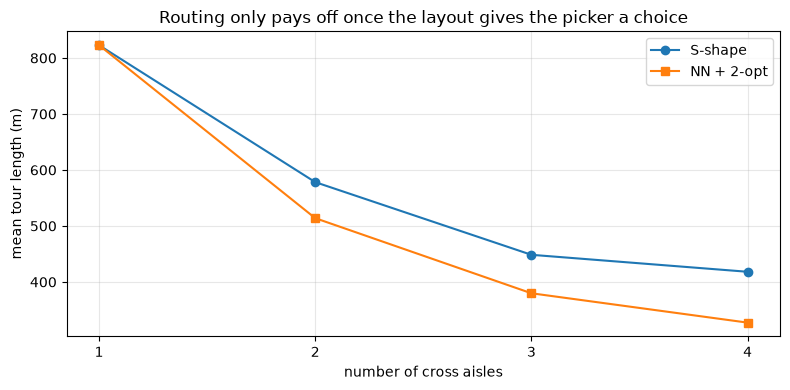

In [6]:
wh = CONFIG.warehouse
rng = np.random.default_rng(0)
tours = []
for _ in range(400):
    n = int(rng.integers(20, 46))
    tours.append((rng.choice(np.arange(wh.n_aisles) * wh.aisle_width, n),
                  rng.uniform(wh.cross_aisle_offset, wh.aisle_length, n)))

rows = []
for n_cross in (1, 2, 3, 4):
    cross = (0.0,) if n_cross == 1 else tuple(
        i * wh.aisle_length / (n_cross - 1) for i in range(n_cross))
    s = np.mean([route_s_shape(x, y, 0.0, cross)[1] for x, y in tours])
    o = np.mean([route_nn_2opt(x, y, 0.0, cross)[1] for x, y in tours])
    rows.append({'cross_aisles': n_cross, 's_shape_m': s, 'nn_2opt_m': o,
                 'routing_gain_pct': 100 * (1 - o / s)})
sweep = pd.DataFrame(rows)
display(sweep.round(2))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sweep.cross_aisles, sweep.s_shape_m, 'o-', label='S-shape')
ax.plot(sweep.cross_aisles, sweep.nn_2opt_m, 's-', label='NN + 2-opt')
ax.set_xlabel('number of cross aisles'); ax.set_ylabel('mean tour length (m)')
ax.set_xticks(sweep.cross_aisles); ax.legend()
ax.set_title('Routing only pays off once the layout gives the picker a choice')
plt.tight_layout(); plt.show()

The gain at one cross aisle is **exactly** zero — not approximately. Measuring anything else there would mean the distance model was wrong, so it is pinned down by a test in `tests/test_optimization.py`.

## 5. Scenario comparison and ablation

Five scenarios, several replications each. Every scenario sees the *same* stochastic streams (congestion, picker skill, truck delays), so the comparison is paired and the confidence interval is on the difference rather than on the level.

In [7]:
raw = report('scenario_raw.csv')
deltas = report('scenario_deltas.csv')

headline = ['on_time_rate', 'distance_per_line_m', 'mean_tardiness_h',
            'mean_orders_per_tour', 'picker_utilisation', 'putaway_distance_per_receipt_m']
display(raw.groupby('scenario')[headline].mean().round(4))

,on_time_rate,distance_per_line_m,mean_tardiness_h,mean_orders_per_tour,picker_utilisation,putaway_distance_per_receipt_m
scenario,,,,,,
baseline,0.9300,8.4604,0.7198,5.2318,0.8348,82.7117
dispatch_only,0.9938,8.6599,0.5082,3.8662,0.8425,82.7117
optimized,0.9944,8.0270,0.4928,3.1591,0.8314,82.6011
risk_escalation,0.9839,8.0262,1.0732,3.1396,0.8309,82.6011
routing_only,0.9409,7.8684,0.6226,3.8218,0.8267,82.7117
slotting_only,0.9346,8.4092,0.6663,5.1943,0.8340,82.6011


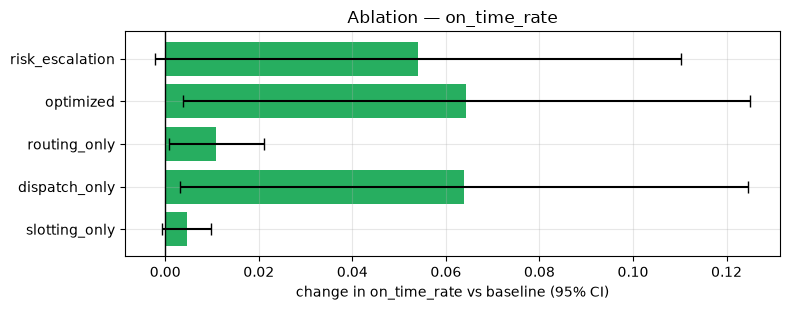

,scenario,baseline_mean,scenario_mean,delta_mean,delta_ci95_low,delta_ci95_high,relative_pct
0,slotting_only,0.93,0.9346,0.0046,-0.0006,0.0098,0.4935
1,dispatch_only,0.93,0.9938,0.0638,0.0032,0.1245,6.8642
2,routing_only,0.93,0.9409,0.0109,0.0008,0.0211,1.1770
3,optimized,0.93,0.9944,0.0644,0.0037,0.1251,6.9249
4,risk_escalation,0.93,0.9839,0.0540,-0.0023,0.1102,5.8033


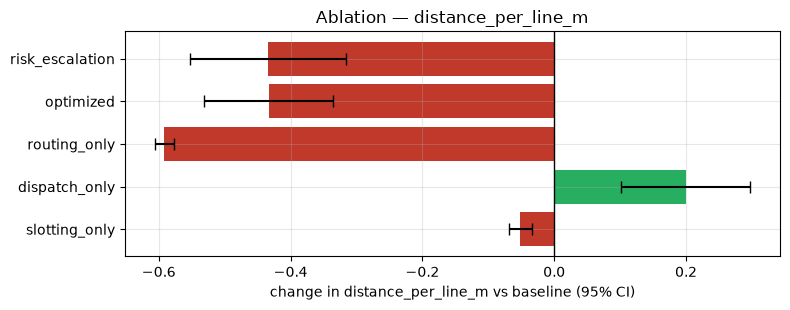

,scenario,baseline_mean,scenario_mean,delta_mean,delta_ci95_low,delta_ci95_high,relative_pct
5,slotting_only,8.4604,8.4092,-0.0512,-0.0689,-0.0335,-0.6053
6,dispatch_only,8.4604,8.6599,0.1995,0.1016,0.2974,2.3579
7,routing_only,8.4604,7.8684,-0.5920,-0.6064,-0.5776,-6.9972
8,optimized,8.4604,8.0270,-0.4334,-0.5320,-0.3349,-5.1232
9,risk_escalation,8.4604,8.0262,-0.4342,-0.5526,-0.3158,-5.1318


In [8]:
for kpi in ['on_time_rate', 'distance_per_line_m']:
    sub = deltas[deltas.kpi == kpi]
    fig, ax = plt.subplots(figsize=(8, 3.2))
    ax.barh(sub.scenario, sub.delta_mean,
            xerr=[sub.delta_mean - sub.delta_ci95_low, sub.delta_ci95_high - sub.delta_mean],
            color=['#c0392b' if v < 0 else '#27ae60' for v in sub.delta_mean], capsize=4)
    ax.axvline(0, color='k', lw=1)
    ax.set_xlabel(f'change in {kpi} vs baseline (95% CI)')
    ax.set_title(f'Ablation — {kpi}')
    plt.tight_layout(); plt.show()
    display(sub[['scenario', 'baseline_mean', 'scenario_mean', 'delta_mean',
                 'delta_ci95_low', 'delta_ci95_high', 'relative_pct']].round(4))

## 6. Stress tests

The models, the forecast and the slot assignment stay exactly as fitted under normal conditions — nothing is refitted. That mismatch is the point: it is what a deployed system faces when conditions move.

The question is not whether the KPIs get worse (they will) but whether the *gap* between baseline and optimised survives.

,condition,baseline,optimized,delta,ci95_low,ci95_high,holds_up
0,normal,0.9300,0.9944,0.0644,0.0037,0.1251,True
1,demand_surge,0.0012,0.9642,0.9629,0.9524,0.9735,True
2,truck_delay_heavy,0.9352,0.9947,0.0595,0.0028,0.1163,True
3,picker_shortage,0.0225,0.9585,0.9360,0.8988,0.9732,True


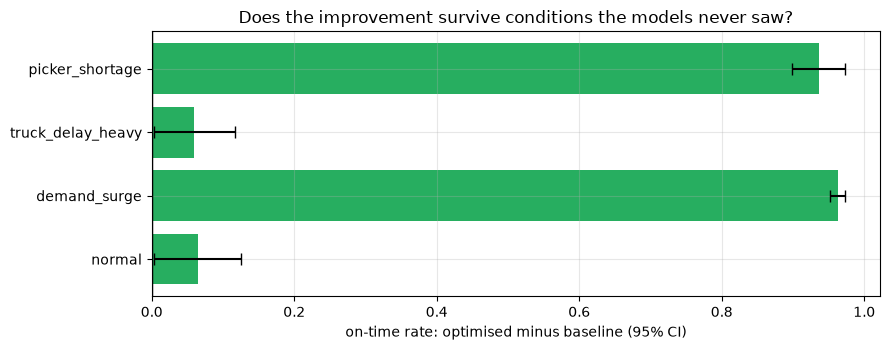

In [9]:
stress = report('stress_summary.csv')
if stress is None:
    print('Run: python -m src.experiments.stress_test')
else:
    display(stress.round(4))
    fig, ax = plt.subplots(figsize=(9, 3.6))
    ax.barh(stress.condition, stress.delta,
            xerr=[stress.delta - stress.ci95_low, stress.ci95_high - stress.delta],
            color=['#27ae60' if h else '#c0392b' for h in stress.holds_up], capsize=4)
    ax.axvline(0, color='k', lw=1)
    ax.set_xlabel('on-time rate: optimised minus baseline (95% CI)')
    ax.set_title('Does the improvement survive conditions the models never saw?')
    plt.tight_layout(); plt.show()

## 7. The load curve, and the number worth quoting

Everything above reads the improvement **vertically**: at a fixed demand, how much better is the service level. A warehouse manager reads the same curve **horizontally**: at a fixed service level, how much more demand can the same building absorb.

The second framing is the one with a budget attached.

scenario,baseline,optimized
orders_per_day,,
150,1.0000,0.9994
175,0.9990,0.9987
200,0.9809,0.9982
225,0.6098,0.9859
250,0.4872,0.9858
275,0.0000,0.9626


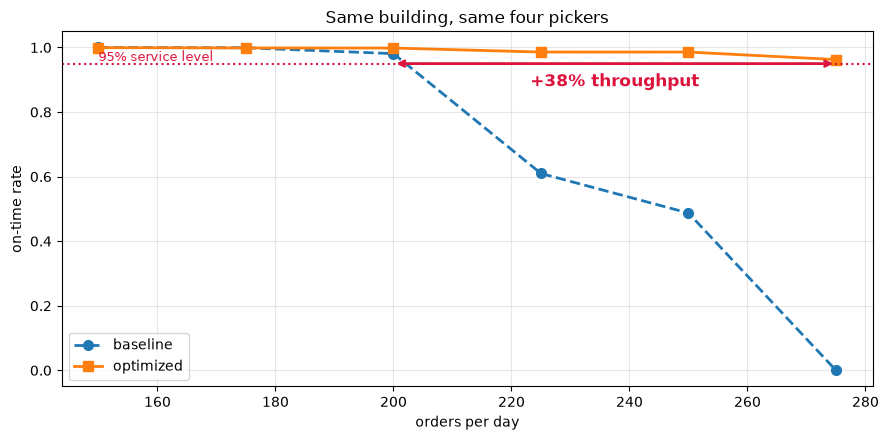

Holding 95% on-time: baseline caps at 200 orders/day, optimised reaches 275.


In [10]:
curve = report('load_curve_raw.csv')
if curve is None:
    print('Run: python -m src.experiments.load_curve')
else:
    pivot = curve.pivot_table(index='orders_per_day', columns='scenario',
                              values='on_time_rate')
    display(pivot.round(4))

    caps = {}
    for scenario in ('baseline', 'optimized'):
        ok = pivot.index[pivot[scenario] >= 0.95]
        caps[scenario] = ok.max() if len(ok) else None

    fig, ax = plt.subplots(figsize=(9, 4.5))
    for scenario, style in [('baseline', 'o--'), ('optimized', 's-')]:
        ax.plot(pivot.index, pivot[scenario], style, lw=2, ms=7, label=scenario)
    ax.axhline(0.95, color='crimson', ls=':', lw=1.5)
    ax.annotate('95% service level', (pivot.index[0], 0.958), fontsize=9, color='crimson')

    if all(caps.values()):
        ax.annotate('', xy=(caps['optimized'], 0.95), xytext=(caps['baseline'], 0.95),
                    arrowprops=dict(arrowstyle='<->', color='crimson', lw=2))
        ax.annotate(f"+{100 * (caps['optimized'] / caps['baseline'] - 1):.0f}% throughput",
                    ((caps['baseline'] + caps['optimized']) / 2, 0.88),
                    ha='center', color='crimson', fontsize=12, weight='bold')

    ax.set_xlabel('orders per day'); ax.set_ylabel('on-time rate')
    ax.set_title('Same building, same four pickers')
    ax.legend(loc='lower left'); plt.tight_layout(); plt.show()

    print(f"Holding 95% on-time: baseline caps at {caps['baseline']} orders/day, "
          f"optimised reaches {caps['optimized']}.")

The baseline does not degrade towards its limit — it falls off a cliff. That is how queueing systems behave near capacity, and it is why planning to run a warehouse "at 95% utilisation" is a far riskier proposition than the number makes it sound.

## What to take away

- The largest single win came from a **scheduling rule, not a model**: triage — the online form of Moore-Hodgson — cut missed trucks by 86% on its own.
- The most natural-looking upgrade to that rule, **least slack, made things worse**. It minimises maximum lateness when the objective is the *count* of late orders. Sophistication in the wrong direction is still the wrong direction.
- **Two of the three ML components did not earn their place**, and the offline metrics did not reveal it — one model even looked better on the metric a dispatcher would naively reach for. Only the end-to-end simulation settled it.
- Routing optimisation was worth 7% of walking distance here and would have been worth **exactly zero** in a single-cross-aisle layout. Where an optimisation acts matters as much as how good it is.
- The honest headline is not the service-level delta but the capacity one: **the same building and the same four pickers absorb 37% more demand** at an unchanged service level.